In [ ]:
"""Problem: Simple Linear Regression using Gradient Descent

Daataset: Create single feature single target dataset using sklearn.datasets.make_regression

Task: Apply Gradient Descent on the dataset with single feature and target, and find the coefficients theta0 and theta1

Use matplotlib to perform data analysis on the dataset and plot scatter of data, plot distribution of feature and target

Normalize the dataset

Apply gradient descent

Calculate the coefficients

Plot the linear regression line

Analyze the model on various values of eta

Analyze the model on different size of data"""

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression


In [3]:
# Generate dataset
n_samples = 100
X, y = make_regression(n_samples=n_samples, n_features=1, noise=30, random_state=42)


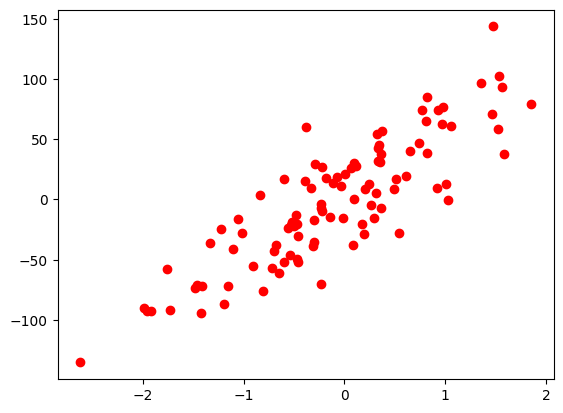

In [4]:
#plot the data points
plt.scatter(X,y,color = 'red')
plt.show()

In [ ]:
#X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [ ]:
#model = LinearRegression().fit(X_train, y_train)
#predict = model.predict(X_test)

In [5]:
# Manual Normalization (Mean Normalization)
X_mean = np.mean(X)
X_std = np.std(X)
X_scaled = (X - X_mean) / X_std  # Standardization (Z-score normalization)

# Add bias term (column of ones)
X_scaled = np.c_[np.ones(X_scaled.shape[0]), X_scaled]


In [6]:
# Initialize parameters
theta = np.zeros(2)
learning_rate = 0.1
iterations = 1000

In [7]:
# Gradient Descent Function
def gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = []

    for i in range(iterations):
        prediction = np.dot(X, theta)
        error = prediction - y
        gradient = (1/m) * np.dot(X.T, error)
        theta -= learning_rate * gradient
        cost = np.sum(error**2) / (2*m)
        cost_history.append(cost)

    return theta, cost_history

In [8]:
# Apply Gradient Descent
theta_final, cost_history = gradient_descent(X_scaled, y, theta, learning_rate, iterations)

# Print final coefficients
print(f"Final Coefficients: theta0 = {theta_final[0]}, theta1 = {theta_final[1]}")


Final Coefficients: theta0 = -1.679254278258948, theta1 = 45.026569996986865


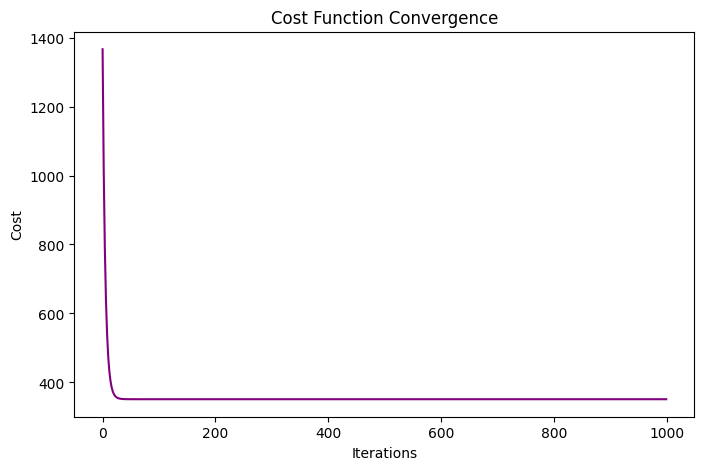

In [9]:
# Plot Cost Function Convergence
plt.figure(figsize=(8, 5))
plt.plot(range(iterations), cost_history, color='purple')
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function Convergence")
plt.show()

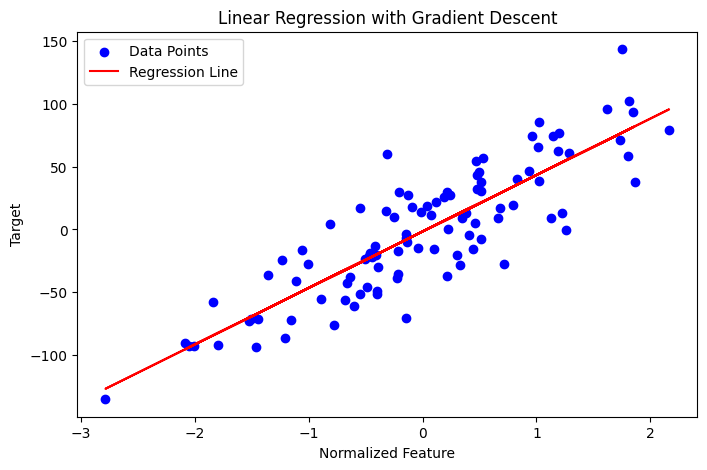

In [10]:

# Plot regression line
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 1], y, color='blue', label="Data Points")
plt.plot(X_scaled[:, 1], np.dot(X_scaled, theta_final), color='red', label="Regression Line")
plt.xlabel("Normalized Feature")
plt.ylabel("Target")
plt.title("Linear Regression with Gradient Descent")
plt.legend()
plt.show()